<a href="https://colab.research.google.com/github/SheilandraZarawiba/PCVK_2026/blob/main/WEEK6_24.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import math
from google.colab.patches import cv2_imshow
from PIL import Image as im

array([[  0,   0,   0, ...,   0,   0,   0],
       [  0, 255,   0, ..., 255, 255,   0],
       [  0, 255, 179, ..., 249, 218,   0],
       ...,
       [  0, 255, 255, ..., 159, 183,   0],
       [  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0]], dtype=uint8)
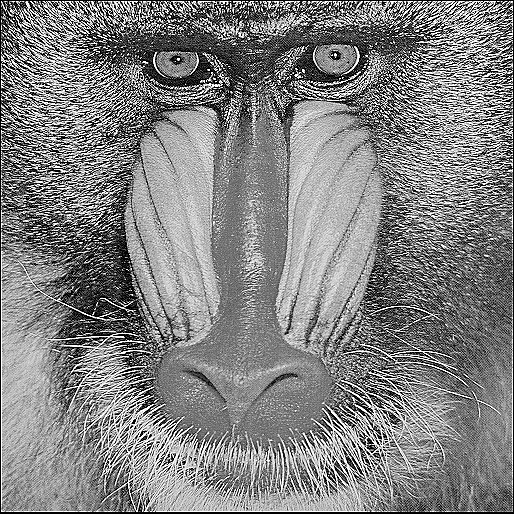

In [9]:
def convolution2d(image, kernel, stride, padding):
    # Menambahkan padding (bingkai 0) pada citra agar piksel pinggir bisa diproses
    image_padded = np.pad(image, ((padding, padding), (padding, padding)), mode='constant')

    kernel_height, kernel_width = kernel.shape
    padded_height, padded_width = image_padded.shape

    # Menghitung ukuran dimensi citra hasil output
    output_height = (padded_height - kernel_height) // stride + 1
    output_width = (padded_width - kernel_width) // stride + 1

    # Menyiapkan matriks kosong berukuran sebesar output
    output = np.zeros((output_height, output_width))

    # Melakukan pergeseran matriks kernel terhadap matriks citra
    for y in range(0, output_height):
        for x in range(0, output_width):
            y_start = y * stride
            y_end = y_start + kernel_height
            x_start = x * stride
            x_end = x_start + kernel_width

            # Perkalian elemen kernel dengan area citra (konvolusi) dan dijumlahkan
            output[y, x] = np.sum(image_padded[y_start:y_end, x_start:x_end] * kernel)

    # Mengembalikan citra yang dibatasi nilainya 0-255 agar tidak error tipe datanya
    return np.clip(output, 0, 255).astype(np.uint8)

img = cv.imread('/content/drive/MyDrive/PCVK/Gambar/mandrill.tiff')
img_gray = cv.cvtColor(img,cv.COLOR_BGR2GRAY)
kernel_sharpen = np.array([[0,-1,0],
                           [-1,5,-1],
                           [0,-1,0]])

convolution2d(img_gray, kernel_sharpen, 1, 2)

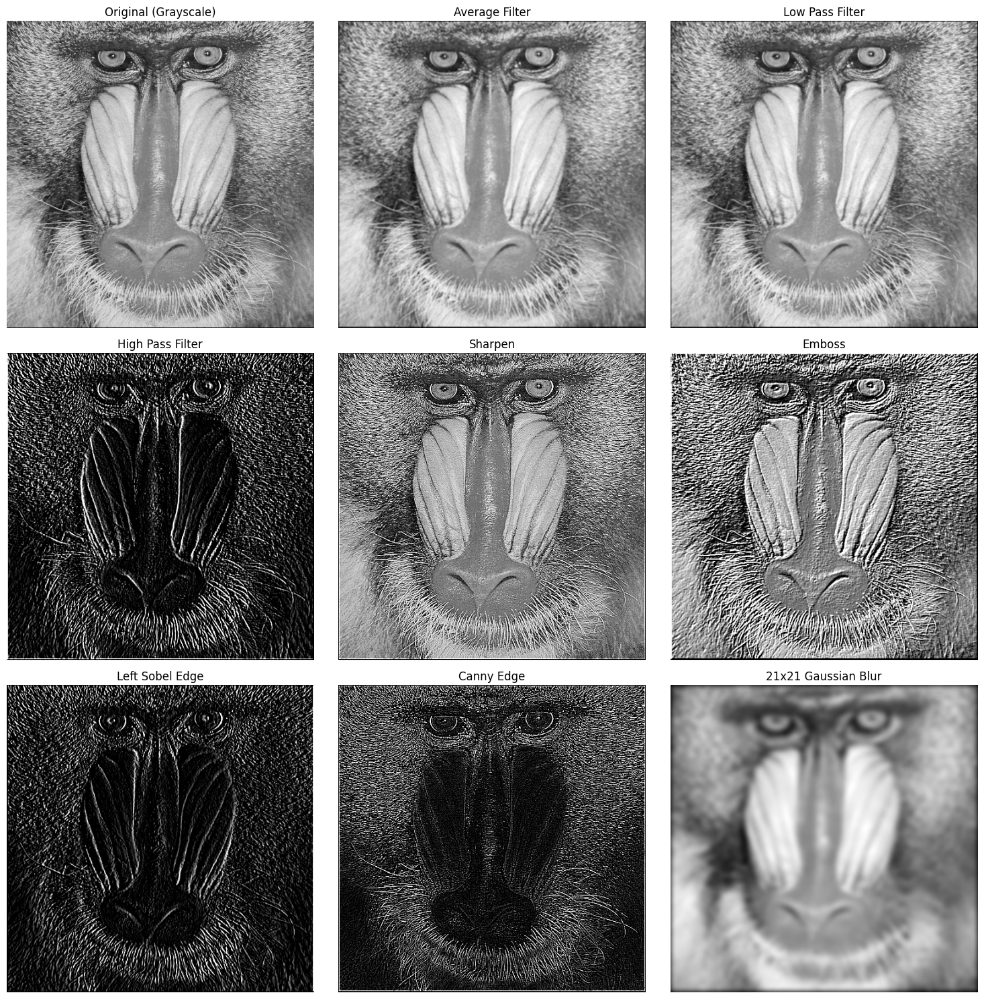

In [10]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
import math

img = cv.imread('/content/drive/MyDrive/PCVK/Gambar/mandrill.tiff')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)


# 1. Average Filter
kernel_average = np.array([[1, 1, 1],
                           [1, 1, 1],
                           [1, 1, 1]]) / 9.0

# 2. Low Pass Filter
kernel_lpf = np.array([[1, 1, 1],
                       [1, 4, 1],
                       [1, 1, 1]]) / 12.0

# 3. High Pass Filter
kernel_hpf = np.array([[-1, 0, 1],
                       [-1, 0, 3],
                       [-3, 0, 1]])

# 4. Sharpen
kernel_sharpen = np.array([[ 0, -1,  0],
                           [-1,  5, -1],
                           [ 0, -1,  0]])

# 5. Emboss
kernel_emboss = np.array([[-2, -1,  0],
                          [-1,  1,  1],
                          [ 0,  1,  2]])

# 6. Left Sobel Edge Detection
kernel_left_sobel = np.array([[ 1,  0, -1],
                              [ 2,  0, -2],
                              [ 1,  0, -1]])

# 7. Canny Edge Detection (Aproksimasi Kernel dari Modul)
kernel_canny = np.array([[-1, -1, -1],
                         [-1,  8, -1],
                         [-1, -1, -1]])

# 8. 21x21 Gaussian Blur
kernel_size = 21
sigma = math.sqrt(kernel_size)
gaussian_kernel1d = cv.getGaussianKernel(kernel_size, sigma)
kernel_gaussian = gaussian_kernel1d @ gaussian_kernel1d.transpose()




res_average    = convolution2d(img_gray, kernel_average, 1, 2)
res_lpf        = convolution2d(img_gray, kernel_lpf, 1, 2)
res_hpf        = convolution2d(img_gray, kernel_hpf, 1, 2)
res_sharpen    = convolution2d(img_gray, kernel_sharpen, 1, 2)
res_emboss     = convolution2d(img_gray, kernel_emboss, 1, 2)
res_left_sobel = convolution2d(img_gray, kernel_left_sobel, 1, 2)
res_canny      = convolution2d(img_gray, kernel_canny, 1, 2)


res_gaussian   = convolution2d(img_gray, kernel_gaussian, 1, 10)


titles = ['Original (Grayscale)', 'Average Filter', 'Low Pass Filter',
          'High Pass Filter', 'Sharpen', 'Emboss',
          'Left Sobel Edge', 'Canny Edge', '21x21 Gaussian Blur']

images = [img_gray, res_average, res_lpf,
          res_hpf, res_sharpen, res_emboss,
          res_left_sobel, res_canny, res_gaussian]

plt.figure(figsize=(15, 15))
for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

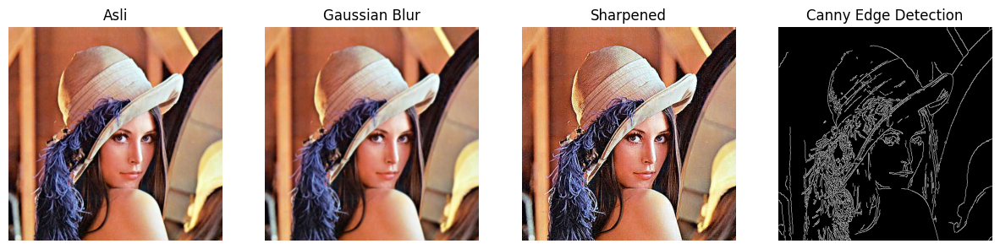

In [12]:
def show_side_by_side(images, titles, figsize=(15,5)):
    plt.figure(figsize=figsize)
    for i, (img, title) in enumerate (zip(images, titles)):
        if len(img.shape) == 2:
            plt.subplot(1, len (images), i+1)
            plt.imshow(img, cmap="gray")
        else:
            plt.subplot(1, len (images), i+1)
            plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis("off")
    plt.show()

lena_path = "/content/drive/MyDrive/PCVK/Gambar/lena.jpg"
img = cv.imread(lena_path)

if img is not None:
    img_gray = cv.cvtColor(img,cv.COLOR_BGR2GRAY)

    blur = cv.GaussianBlur(img, (7,7), 1)
    edges = cv.Canny(cv.cvtColor(img, cv.COLOR_BGR2GRAY), 100, 200)
    sharpen_kernel = np.array([[0,-1,0], [-1,5,-1], [0,-1,0]])
    sharpened = cv.filter2D (img, -1, sharpen_kernel)

    show_side_by_side([img, blur, sharpened, edges],
                      ["Asli", "Gaussian Blur", "Sharpened", "Canny Edge Detection"])

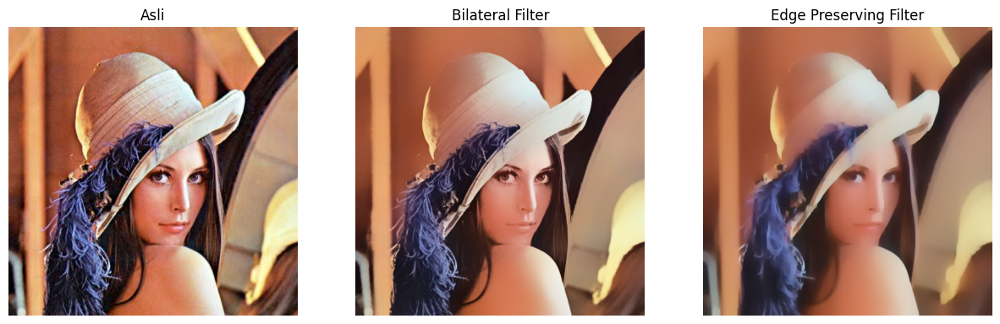

In [13]:
    bilateral = cv.bilateralFilter(img, 58, 100, 100)

    edge_preserve = cv.edgePreservingFilter(img, flags=1, sigma_s=100, sigma_r=0.9)

    show_side_by_side([img, bilateral, edge_preserve],
                      ["Asli", "Bilateral Filter", "Edge Preserving Filter"])

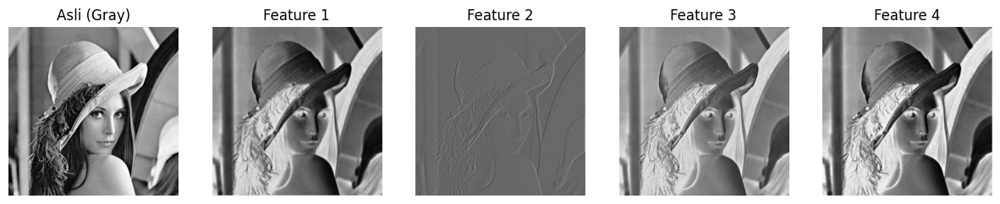

In [14]:
    import torch
    import torch.nn as nn

    class SimpleCNN(nn.Module):
        def __init__(self):
            super (SimpleCNN, self).__init__()
            self.conv1 = nn.Conv2d(1, 4, kernel_size=3, stride=1, padding=1)

        def forward(self, x):
            return self.conv1(x)

    model = SimpleCNN()

    img_tensor = torch.tensor(img_gray, dtype=torch.float32).unsqueeze(0).unsqueeze(0) / 255.0

    with torch.no_grad():
        features = model(img_tensor)

    feature_maps = [features[0, i].numpy() for i in range(features.shape[1])]
    show_side_by_side([img_gray] + feature_maps, ["Asli (Gray)"] + [f"Feature {i+1}" for i in range(len(feature_maps))])

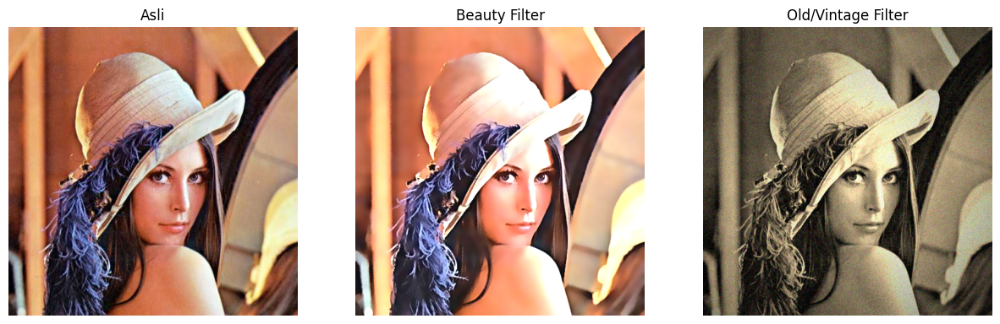

In [17]:
    smooth = cv.bilateralFilter(img, d=15, sigmaColor=75, sigmaSpace=75)
    gaussian = cv.GaussianBlur(smooth, (0,0), 3)
    sharpened_b = cv.addWeighted(smooth, 1.5, gaussian, -0.5, 0)
    alpha = 1.2
    beta = 15
    beauty = cv.convertScaleAbs(sharpened_b, alpha=alpha, beta=beta)

    sepia_kernel = np.array([[0.272, 0.534, 0.131],
                             [0.349, 0.686, 0.168],
                             [0.393, 0.769, 0.189]])
    sepia = cv.transform(img, sepia_kernel)
    sepia = np.clip(sepia, 0, 255).astype(np.uint8)
    rows, cols = img.shape[:2]
    kernel_x = cv.getGaussianKernel(cols, cols*0.6)
    kernel_y = cv.getGaussianKernel(rows, rows*0.6)
    kernel = kernel_y * kernel_x.T
    mask = kernel / kernel.max()
    vignette = np.copy(sepia)
    for i in range(3):
        vignette[:,:,i] = vignette[:,:,i] * mask
    noise = np.random.normal(0, 15, vignette.shape).astype(np.int16)
    old_img = np.clip(vignette.astype(np.int16) + noise, 0, 255).astype(np.uint8)
    show_side_by_side([img, beauty, old_img], ["Asli", "Beauty Filter", "Old/Vintage Filter"])

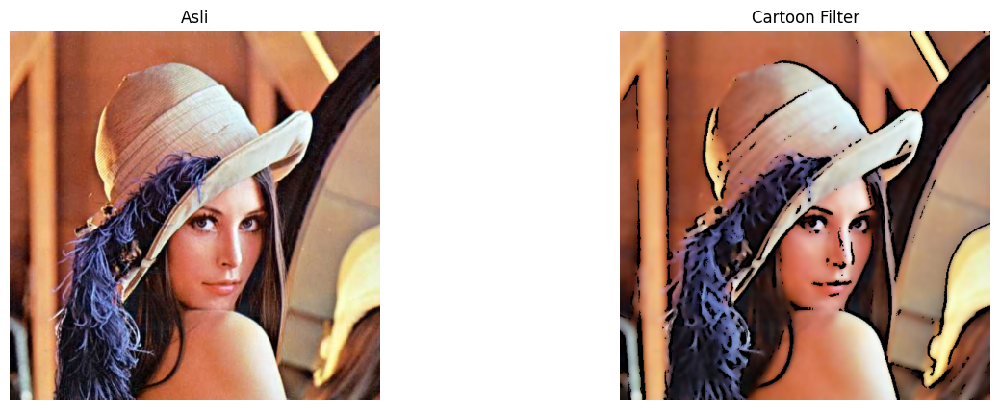

In [18]:
    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    gray_blur = cv.medianBlur(gray, 7)
    edges_c = cv.adaptiveThreshold(gray_blur, 255, cv.ADAPTIVE_THRESH_MEAN_C, cv.THRESH_BINARY, 9, 9)
    color = cv.bilateralFilter(img, d=9, sigmaColor=200, sigmaSpace=200)
    cartoon = cv.bitwise_and(color, color, mask=edges_c)

    show_side_by_side([img, cartoon], ["Asli", "Cartoon Filter"])

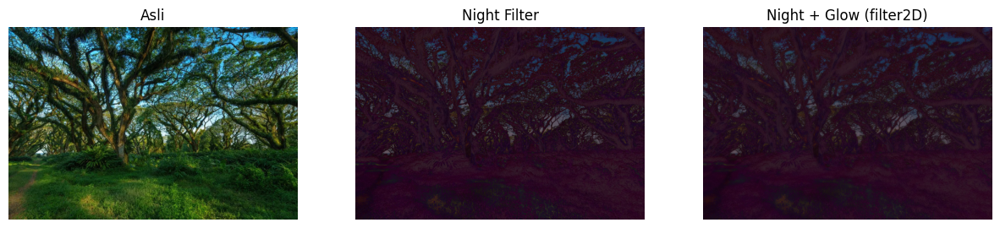

In [19]:
djawatan_path = "/content/drive/MyDrive/PCVK/Gambar/djawatan.jpg"
img_djawatan = cv.imread(djawatan_path)

if img_djawatan is not None:
    img_gray_dj = cv.cvtColor(img_djawatan,cv.COLOR_BGR2GRAY)

    night = cv.convertScaleAbs(img_djawatan, alpha=0.6, beta=-40)

    blue_tint = np.full_like(night, (50, 0, 100))
    night = cv.addWeighted(night, 0.8, blue_tint, 0.2, 0)

    kernel = np.ones((15,15), np.float32)/225
    glow = cv.filter2D(night, -1, kernel)

    night_glow = cv.addWeighted(night, 0.7, glow, 0.3, 0)

    show_side_by_side([img_djawatan, night, night_glow], ["Asli", "Night Filter", "Night + Glow (filter2D)"])

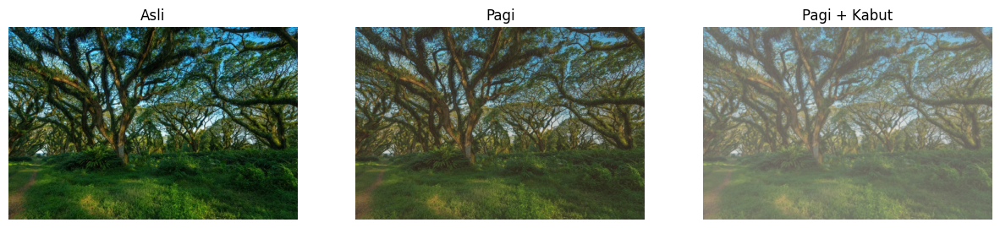

In [20]:
    alpha_p = 0.9
    beta_p = 20
    soft = cv.convertScaleAbs(img_djawatan, alpha=alpha_p, beta=beta_p)

    warm_tint = np.full_like(soft, (40, 70, 120))
    pagi = cv.addWeighted(soft, 0.8, warm_tint, 0.2, 0)

    kernel_k = cv.getGaussianKernel(3, 3)
    kernel_k = kernel_k @ kernel_k.T
    kabut = cv.filter2D(pagi, -1, kernel_k)

    white_layer = np.full_like(pagi, 255)
    kabut = cv.addWeighted(kabut, 0.7, white_layer, 0.3, 0)

    show_side_by_side([img_djawatan, pagi, kabut], ["Asli", "Pagi", "Pagi + Kabut"])

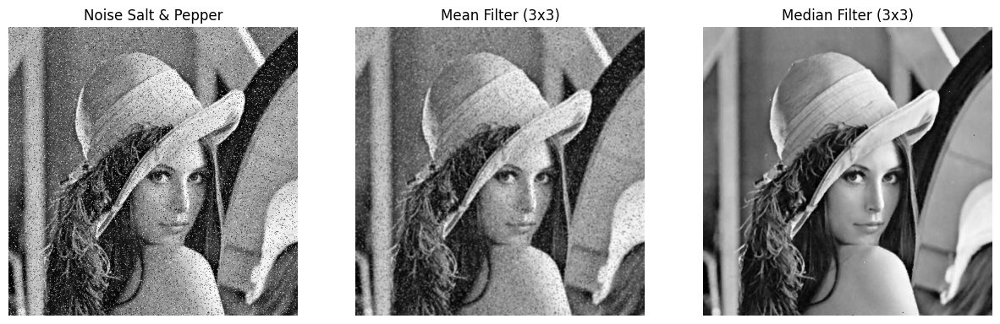

In [21]:
# JAWABAN NOMOR 1
if img is not None:
    img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    noise_img = img_gray.copy()

    prob = 0.05
    thres = 1 - prob
    for i in range(noise_img.shape[0]):
        for j in range(noise_img.shape[1]):
            rdn = np.random.random()
            if rdn < prob:
                noise_img[i][j] = 0
            elif rdn > thres:
                noise_img[i][j] = 255

    mean_blur = cv.blur(noise_img, (3, 3))
    median_blur = cv.medianBlur(noise_img, 3)

    show_side_by_side([noise_img, mean_blur, median_blur],
                      ["Noise Salt & Pepper", "Mean Filter (3x3)", "Median Filter (3x3)"])

**Jawaban no 1**
Dari hasil percobaan pada gambar, Median Filter terbukti jauh lebih ampuh untuk membersihkan noise bintik hitam-putih (Salt & Pepper) dibandingkan Mean Filter. Hal ini terjadi karena Mean Filter bekerja dengan cara merata-rata seluruh nilai piksel di sekitarnya, sehingga nilai ekstrem dari noise malah ikut menyebar dan membuat citra tampak kotor atau buram. Sebaliknya, Median Filter hanya mengambil nilai tengah dari deretan piksel tetangganya. Karena noise Salt & Pepper selalu berada di nilai ekstrem (terkecil atau terbesar), nilai tersebut otomatis diabaikan dan langsung digantikan oleh intensitas warna asli di sekitarnya sehingga hasil akhirnya jauh lebih bersih.

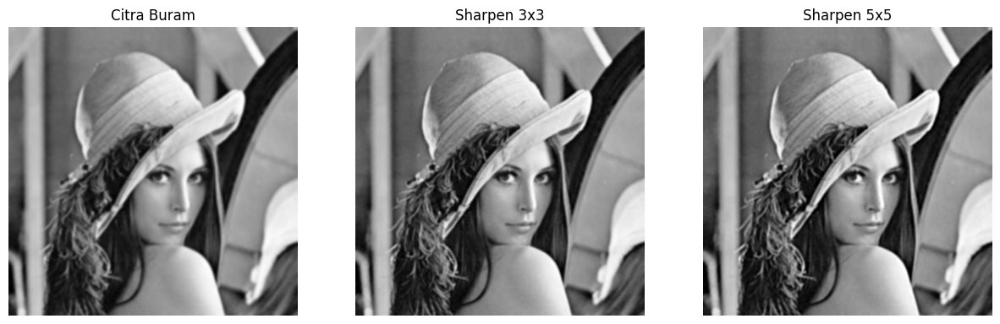

In [22]:
# JAWABAN NOMOR 2
if img is not None:
    img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    img_blurry = cv.GaussianBlur(img_gray, (9,9), 0)

    kernel_sharp_3x3 = np.array([[ 0, -1,  0],
                                 [-1,  5, -1],
                                 [ 0, -1,  0]])

    kernel_sharp_5x5 = np.array([[-1, -1, -1, -1, -1],
                                 [-1,  2,  2,  2, -1],
                                 [-1,  2,  9,  2, -1],
                                 [-1,  2,  2,  2, -1],
                                 [-1, -1, -1, -1, -1]]) / 9.0

    sharp_result_3x3 = cv.filter2D(img_blurry, -1, kernel_sharp_3x3)
    sharp_result_5x5 = cv.filter2D(img_blurry, -1, kernel_sharp_5x5)

    show_side_by_side([img_blurry, sharp_result_3x3, sharp_result_5x5],
                      ["Citra Buram", "Sharpen 3x3", "Sharpen 5x5"])

**Jawaban no 2**
Berdasarkan perbandingan visual yang dihasilkan, kernel ukuran 3x3 memberikan hasil penajaman tepi yang paling proporsional dan natural. Saat kita menggunakan kernel 5x5, area piksel yang dievaluasi menjadi lebih luas, sehingga tarikan kontrasnya terlalu keras dan malah memunculkan banyak tekstur kasar atau noise artifact pada area gambar yang seharusnya halus. Oleh karena itu, untuk penggunaan sehari-hari, kernel 3x3 merupakan pilihan yang paling ideal karena mampu mengembalikan fokus pada citra yang buram tanpa merusak kualitas gambar secara keseluruhan.

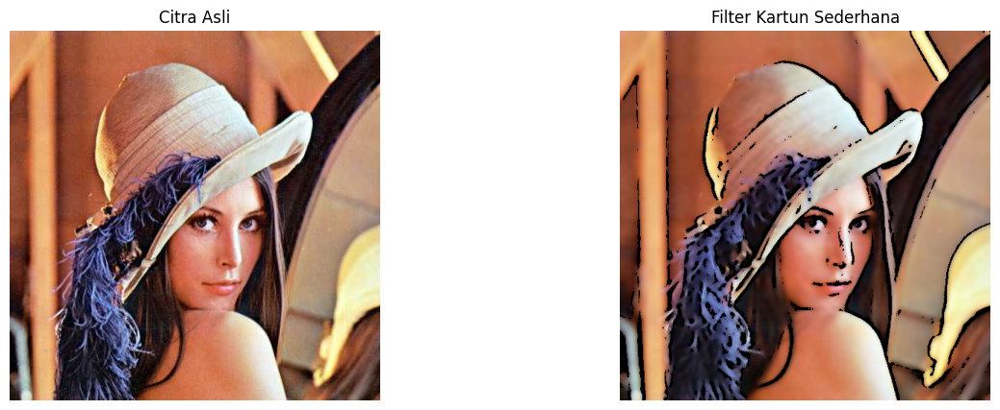

In [23]:
# JAWABAN NOMOR 3
if img is not None:
    def kartun(image):
        color_smooth = cv.bilateralFilter(image, d=9, sigmaColor=200, sigmaSpace=200)

        gray_img = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
        gray_blur = cv.medianBlur(gray_img, 7)
        edges = cv.adaptiveThreshold(gray_blur, 255, cv.ADAPTIVE_THRESH_MEAN_C, cv.THRESH_BINARY, 9, 9)

        cartoon_result = cv.bitwise_and(color_smooth, color_smooth, mask=edges)
        return cartoon_result

    hasil_kartun = kartun(img)
    show_side_by_side([img, hasil_kartun], ["Citra Asli", "Filter Kartun Sederhana"])

**Jawaban no 3**
Efek visual bergaya komik atau kartun pada percobaan ini sukses dibuat melalui penggabungan dua teknik filter spasial yang bekerja secara bersamaan. Langkah pertama menggunakan Bilateral Filter untuk meratakan warna dan menghaluskan tekstur gambar, sehingga warnanya tampak solid seperti sapuan cat namun tetap mempertahankan batas objek. Kemudian, teknik edge detection seperti Adaptive Thresholding diterapkan untuk mencari garis tepi dari objek-objek tersebut dan mengubahnya menjadi outline hitam yang tegas. Ketika warna solid dan garis tepi hitam ini ditumpuk menjadi satu, gambar foto asli akan terlihat seperti gambar ilustrasi dua dimensi.